# Import Library

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Read Dataset

In [4]:
df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# Informasi DataSet

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [8]:
print(df.describe())

                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

           sqft_lot        floors    waterfront          view     condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      0.086517    

# Cek Missing Value

In [13]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

# Melihat Korelasi Antar Variable

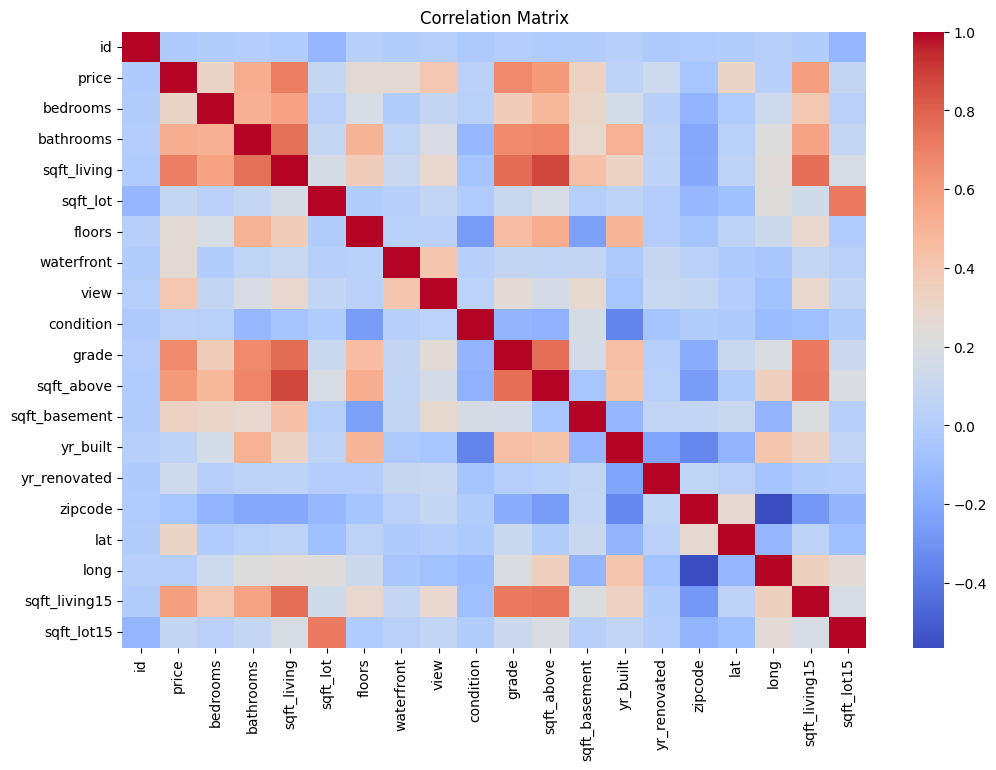

In [15]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Merah → hubungan kuat naik bersama
Biru → hubungan berlawanan
Putih → tidak terlalu berhubungan

# REGRESSION MODEL

Feature Selection

In [16]:
X = df[['bedrooms','bathrooms','sqft_living','floors','grade']]
y = df['price']

Split Data

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Model

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Prediksi Harga

In [20]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 525658.55547265  699920.49890955 1194825.95262054 1497709.26758439
  767650.47823838  368930.58746092  758833.8376283   442878.61350966
  459725.49974235  301398.4216016 ]


# Evaluasi Model

In [28]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("RMSE :", rmse)

R2 Score : 0.5505426194978675
RMSE : 260667.39167738525


# Visualisasi Prediksi

Prediksi Masih Tidak Bagus karna data nya masih menyebar banyak

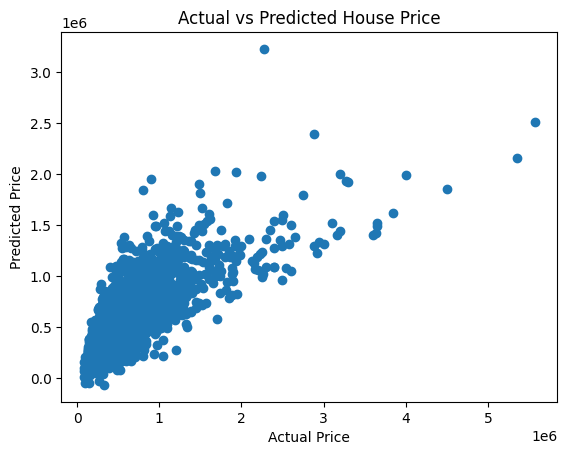

In [30]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

# CLASSIFICATION MODEL

Buat Kolom Kategori Harga

In [31]:
median_price = df['price'].median()

df['price_category'] = (df['price'] > median_price).astype(int)

Feature & Target

In [33]:
X = df[['bedrooms','bathrooms','sqft_living','floors','grade']]
y = df['price_category']

Splitting Data

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression

In [35]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

Evaluasi Logistic Regression

In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision :", precision_score(y_test, y_pred_log))
print("Recall :", recall_score(y_test, y_pred_log))

Accuracy : 0.7624334952579227
Precision : 0.7935222672064778
Recall : 0.7169638774577046


# Decision Tree

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

Evaluasi Decision Tree

In [38]:
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision :", precision_score(y_test, y_pred_tree))
print("Recall :", recall_score(y_test, y_pred_tree))

Accuracy : 0.7281980106407587
Precision : 0.7610939112487101
Recall : 0.6744398719707362


# VISUALISASI DISTRIBUSI HARGA

Grafik distribusi harga rumah menunjukkan bahwa sebagian besar rumah memiliki harga pada rentang 300.000 hingga 700.000. Distribusi data bersifat right-skewed, di mana terdapat beberapa rumah dengan harga sangat tinggi yang menyebabkan ekor distribusi memanjang ke arah kanan. Hal ini menunjukkan bahwa rumah dengan harga tinggi jumlahnya jauh lebih sedikit dibandingkan rumah dengan harga menengah

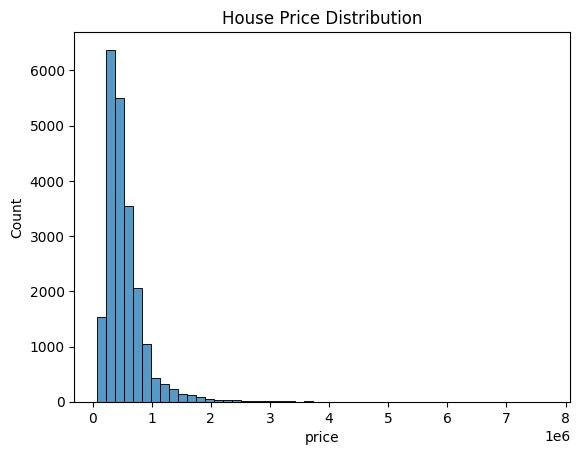

In [39]:
sns.histplot(df['price'], bins=50)
plt.title("House Price Distribution")
plt.show()

Hubungan antaran Luas Rumas Dgn Harga Rumah

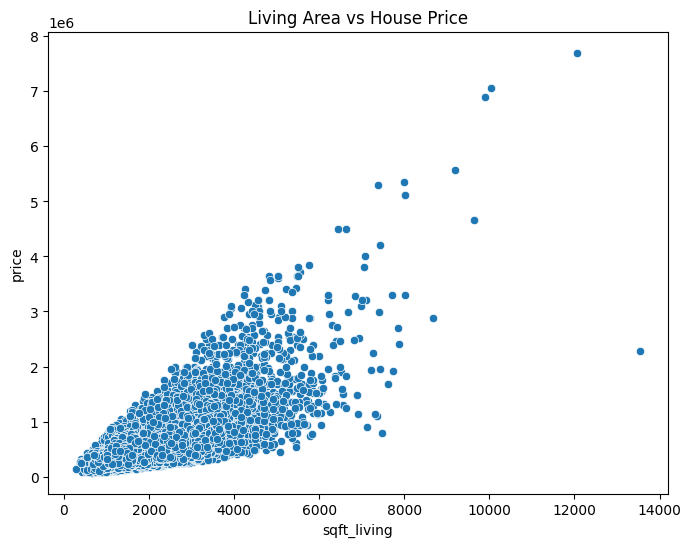

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Living Area vs House Price")
plt.show()